<a href="https://colab.research.google.com/github/Kseniaa31/Data-Science/blob/Password-Strength/Password.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA COLLECTION**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
from warnings import filterwarnings
filterwarnings("ignore")
con = sqlite3.connect("password_data.sqlite")

In [2]:
data = pd.read_sql_query("SELECT * FROM Users", con)
data.head(4)

,index,password,strength
0,0,zxe870819,1
1,1,xw46454nr23l,1
2,2,soporte13,1
3,3,accounts6000webhost.com,2


# **DATA CLEANING**

In [3]:
data.drop(["index"],axis=1, inplace=True) #Index is not relevant so we drop
data.head(4)

,password,strength
0,zxe870819,1
1,xw46454nr23l,1
2,soporte13,1
3,accounts6000webhost.com,2


In [4]:
data.duplicated().sum() #no duplicate
data.isnull().any().sum() #no missing values

np.int64(0)

In [5]:
data.dtypes

,0
password,object
strength,int64


In [6]:
data["strength"].unique()

array([1, 2, 0])

# **DATA ANALYSIS**

**SEMANTIC ANALYSIS**

In [7]:
type(data["password"][0])
#we need to use string functions

str

In [8]:
data[data["password"].str.isnumeric()].shape

(26, 2)

In [9]:
data[data["password"].str.isupper()].shape

(1506, 2)

In [10]:
data[data["password"].str.isalpha()].shape

(50, 2)

In [11]:
data[data["password"].str.isalnum()].shape

(97203, 2)

In [12]:
data[data["password"].str.istitle()].shape #title: first character is upper case

(932, 2)

In [13]:
import string
def find_semantics(row):
  for char in row:
    if char in string.punctuation:
      return 1
    else:
      pass

In [14]:
data[data["password"].apply(find_semantics)==1]

,password,strength
3,accounts6000webhost.com,2
68,12463773800+,1
98,p.r.c.d.g.,1
145,cita-cita,1
180,karolina.susnina0U,2
...,...,...
99748,maiselis.com,1
99845,hosting4meze!@#,2
99954,semista_bakung15,2
99980,halflife2010!LEB,2


# **FEATURE ENGINEERING**

In [15]:
data["length"]=data["password"].str.len()

In [16]:
def freq_lowercase(row):
  return len([char for char in row if char.islower()])/len(row)

def freq_uppercase(row):
  return len([char for char in row if char.isupper()])/len(row)

def freq_numericalcase(row):
  return len([char for char in row if char.isdigit()])/len(row)

def freq_specialcase(row):
  special_chars=[]
  for char in row:
    if not char.isalpha() and not char.isdigit():
      special_chars.append(char)
  return len(special_chars)/len(row)


In [17]:
data["lowercase_freq"]=np.round(data["password"].apply(freq_lowercase),3)
data["uppercase_freq"]=np.round(data["password"].apply(freq_uppercase),3)
data["digit_freq"]=np.round(data["password"].apply(freq_numericalcase),3)
data["specialChars_freq"]=np.round(data["password"].apply(freq_specialcase),3)
data.head(4)

,password,strength,length,lowercase_freq,uppercase_freq,digit_freq,specialChars_freq
0,zxe870819,1,9,0.333,0.0,0.667,0.000
1,xw46454nr23l,1,12,0.417,0.0,0.583,0.000
2,soporte13,1,9,0.778,0.0,0.222,0.000
3,accounts6000webhost.com,2,23,0.783,0.0,0.174,0.043


**DESCRIPTIVE STATISTICS**

In [18]:
cols=['length','lowercase_freq', 'uppercase_freq','digit_freq','specialChars_freq']
for col in cols:
  print(col)
  print(data[[col, 'strength']].groupby(['strength']).agg(["min","max","mean","median"]))
  print('\n')

length
         length                       
            min  max       mean median
strength                              
0             1    7   6.550947    7.0
1             8   13   9.611074    9.0
2            14  220  15.953421   16.0


lowercase_freq
         lowercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.708050  0.714
1                   0.0  0.923  0.630067  0.667
2                   0.0  0.917  0.424679  0.400


uppercase_freq
         uppercase_freq                        
                    min    max      mean median
strength                                       
0                   0.0  1.000  0.012872  0.000
1                   0.0  0.923  0.007915  0.000
2                   0.0  0.889  0.367633  0.429


digit_freq
         digit_freq                        
                min    max      mean median
strength                                   
0   

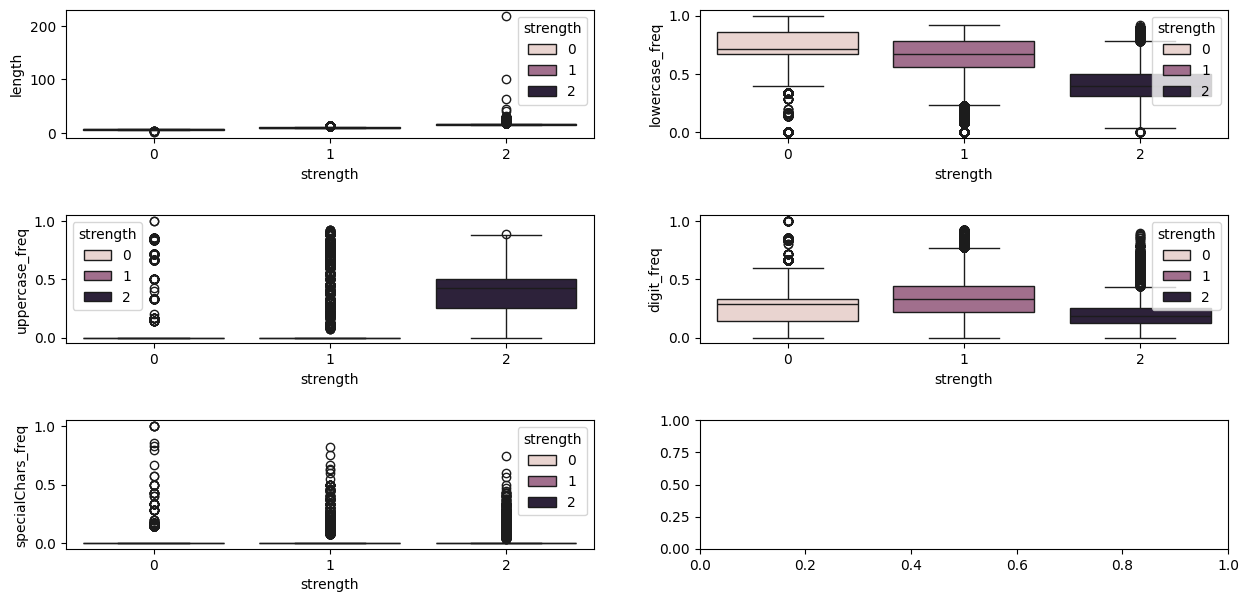

In [19]:
fig, ((ax1,ax2),(ax3,ax4),(ax5,ax6))=plt.subplots(3,2, figsize=(15,7))
sns.boxplot(x="strength",y="length", hue="strength",ax=ax1, data=data)
sns.boxplot(x="strength",y="lowercase_freq", hue="strength",ax=ax2, data=data)
sns.boxplot(x="strength",y="uppercase_freq", hue="strength", ax=ax3, data=data)
sns.boxplot(x="strength",y="digit_freq", hue="strength", ax=ax4, data=data)
sns.boxplot(x="strength",y="specialChars_freq", hue="strength", ax=ax5, data=data)
plt.subplots_adjust(hspace=0.6)

**FEATURE IMPORTANCE**

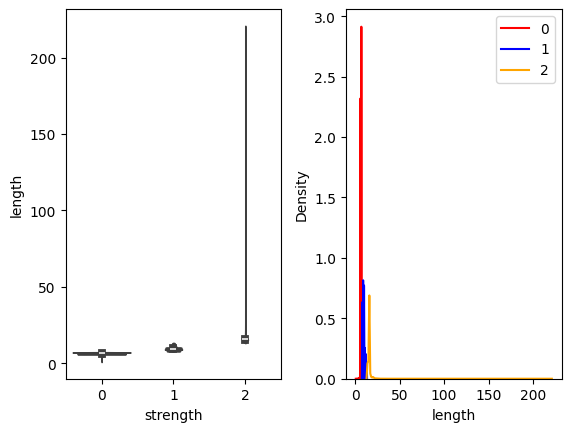

In [20]:
def get_dist(data, feature):
  plt.subplot(1,2,1)
  sns.violinplot(x="strength", y=feature, data=data)
  plt.subplot(1,2,2)
  sns.distplot(data[data['strength']==0][feature], color="red", label="0", hist=False)
  sns.distplot(data[data['strength']==1][feature], color="blue", label="1", hist=False)
  sns.distplot(data[data['strength']==2][feature], color="orange", label="2", hist=False)
  plt.subplots_adjust(wspace=0.3)
  plt.legend()
  plt.show()

get_dist(data, "length")

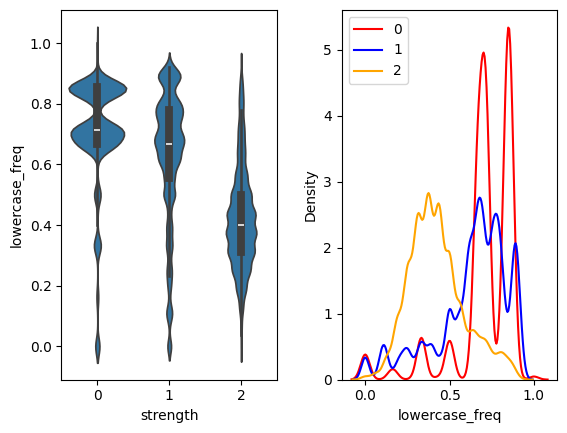

In [21]:
get_dist(data, 'lowercase_freq')

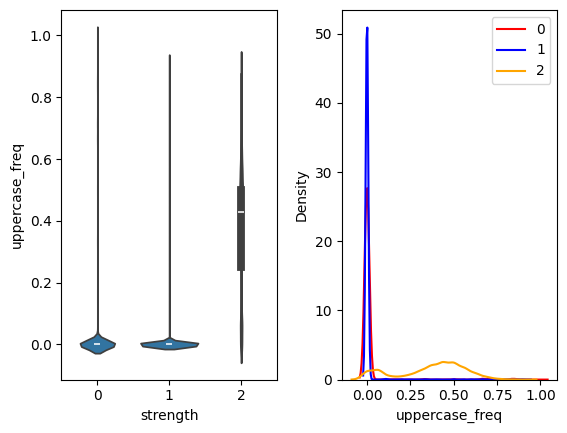

In [22]:
get_dist(data, 'uppercase_freq')

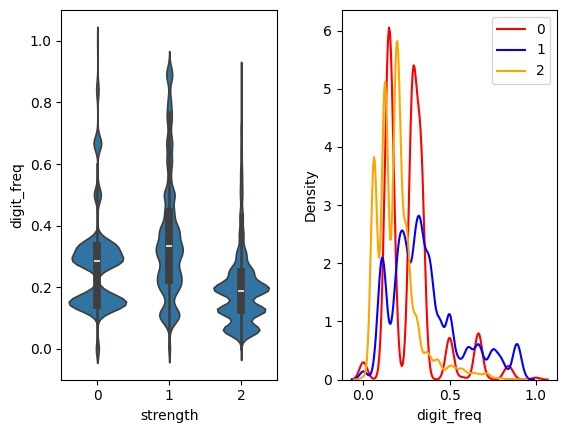

In [23]:
get_dist(data, 'digit_freq')

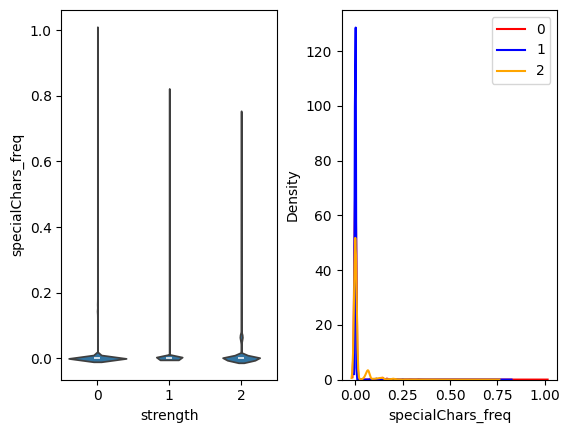

In [24]:
get_dist(data, 'specialChars_freq')

**NLP TECHNIQUES**

In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(analyzer="char")

In [26]:
dataframe=data.sample(frac=1)
x = list(dataframe["password"])
X=vectorizer.fit_transform(x)
print(X.shape)
print(dataframe['password'].shape)

(100000, 99)
(100000,)


In [27]:
df2 = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
df2

,,,,,,,,,!,#,...,ñ,ó,õ,ö,÷,ú,ü,ý,þ,›
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **ML MODEL BUILDING**

In [28]:
#length and lowercase features are found to be the most important ones in terms of password strength
df2['length']=dataframe['length']
df2['lowercase_freq']=dataframe['lowercase_freq']
df2

,,,,,,,,,!,#,...,õ,ö,÷,ú,ü,ý,þ,›,length,lowercase_freq
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.333
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12,0.417
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,0.783
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8,0.625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.700
99996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10,0.800
99997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.778
99998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,0.667


In [29]:
from sklearn.model_selection import train_test_split
y= dataframe["strength"]
X_train, X_test, y_train, y_test= train_test_split(df2,y,test_size=0.20)
X_train.shape

(80000, 101)

In [31]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(multi_class="multinomial")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 1, ..., 2, 1, 1])

In [32]:
from collections import Counter
Counter(y_pred)

Counter({np.int64(1): 16771, np.int64(0): 1425, np.int64(2): 1804})

In [41]:
def predict(): #prediction on user entered input
  password = input("Enter a password : ")
  sample_array=np.array([password])
  sample_matrix=vectorizer.transform(sample_array)
  length_pass= len(password)
  length_normalized_lowercase= len([char for char in password if char.islower()])/len(password)
  new_matrix=np.append(sample_matrix.toarray(), (length_pass, length_normalized_lowercase)).reshape(1,101)
  result = clf.predict(new_matrix)
  if result==0:
    print("Weak Password")
  elif result==1:
    print("Normal Password")
  else:
    print("Strong Password")

predict()

Enter a password : password1.
Strong Password


In [42]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[  760  2049     2]
 [  597 13754   326]
 [   68   968  1476]]
0.7995
              precision    recall  f1-score   support

           0       0.53      0.27      0.36      2811
           1       0.82      0.94      0.87     14677
           2       0.82      0.59      0.68      2512

    accuracy                           0.80     20000
   macro avg       0.72      0.60      0.64     20000
weighted avg       0.78      0.80      0.78     20000

